In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

print("SVM Fake News Detector - Simple Model")
print("="*60)

SVM Fake News Detector - Simple Model


In [6]:
DATA_PATH = "../data/raw/multinli_1.0/multinli_1.0_train.jsonl"

data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item["gold_label"] != "-":
            data.append(item)

data = data[:4000]

df = pd.DataFrame(data)[["sentence1", "sentence2", "gold_label"]]

print(f"Dataset: {len(df)} samples")
print("\nLabel distribution:")
print(df["gold_label"].value_counts())

Dataset: 4000 samples

Label distribution:
gold_label
contradiction    1469
entailment       1371
neutral          1160
Name: count, dtype: int64


In [7]:
label_mapping = {"entailment": 0, "neutral": 1, "contradiction": 2}

sentence1_texts = df["sentence1"].values
sentence2_texts = df["sentence2"].values
labels = df["gold_label"].map(label_mapping).values

print(f"Sentence1 shape: {sentence1_texts.shape}")
print(f"Sentence2 shape: {sentence2_texts.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nExample sentence1:\n{sentence1_texts[0][:100]}...")
print(f"Example sentence2:\n{sentence2_texts[0][:100]}...")

Sentence1 shape: (4000,)
Sentence2 shape: (4000,)
Labels shape: (4000,)

Example sentence1:
Conceptually cream skimming has two basic dimensions - product and geography....
Example sentence2:
Product and geography are what make cream skimming work. ...


In [8]:
print("Vectorizing sentence1 and sentence2 with TF-IDF...")
vectorizer1 = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=2, ngram_range=(1, 2))
vectorizer2 = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=2, ngram_range=(1, 2))

X1 = vectorizer1.fit_transform(sentence1_texts)
X2 = vectorizer2.fit_transform(sentence2_texts)

# Combine features (e.g., horizontally)
from scipy.sparse import hstack
X = hstack([X1, X2])
print(f"✓ Combined vectorized shape: {X.shape}")

Vectorizing sentence1 and sentence2 with TF-IDF...
✓ Combined vectorized shape: (4000, 10000)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Train samples: 3200
Test samples: 800
Features: 10000


In [10]:
print("Training SVM classifier...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("✓ Training complete")

Training SVM classifier...
✓ Training complete


In [11]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = ["Entailment (VRAI)", "Neutral (À_VÉRIFIER)", "Contradiction (FAUX)"]
print(classification_report(y_test, y_pred, target_names=target_names))

Test Accuracy: 0.4562
Cohen's Kappa: 0.1639

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

   Entailment (VRAI)       0.43      0.57      0.49       274
Neutral (À_VÉRIFIER)       0.39      0.11      0.17       232
Contradiction (FAUX)       0.50      0.62      0.55       294

            accuracy                           0.46       800
           macro avg       0.44      0.43      0.40       800
        weighted avg       0.44      0.46      0.42       800



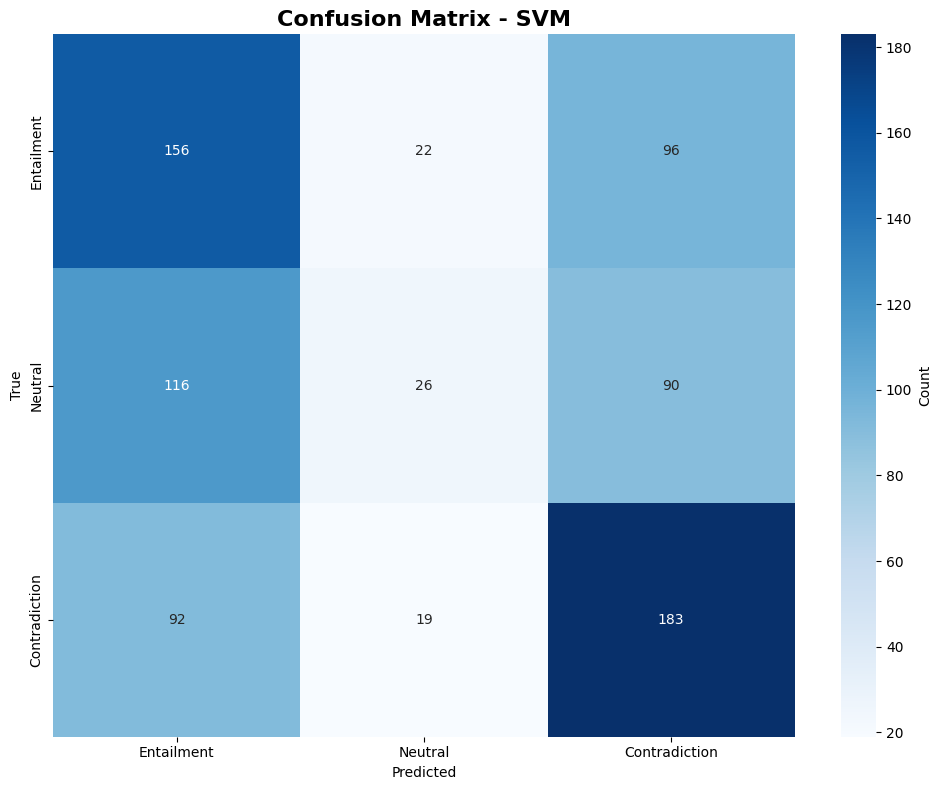

Entailment: 0.5693
Neutral: 0.1121
Contradiction: 0.6224


In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Entailment", "Neutral", "Contradiction"],
    yticklabels=["Entailment", "Neutral", "Contradiction"],
    cbar_kws={"label": "Count"}
)
plt.title("Confusion Matrix - SVM", fontsize=16, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

for i, label in enumerate(["Entailment", "Neutral", "Contradiction"]):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{label}: {class_acc:.4f}")